<a href="https://colab.research.google.com/github/2626245/ACML_PROJECT/blob/main/model_variation1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
print("Copying dataset to local storage...")
shutil.copytree(
    '/content/drive/MyDrive/chest_xray_processed',
    '/content/chest_xray_processed'
)
print("Done!")

Copying dataset to local storage...
Done!


In [ ]:
import os

data_dir = '/content/drive/MyDrive/chest_xray_processed'

for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(data_dir, split, cls)
        count = len(os.listdir(path))
        print(f"{split}/{cls}: {count} images")

train/NORMAL: 1108 images
train/PNEUMONIA: 2991 images
val/NORMAL: 237 images
val/PNEUMONIA: 641 images
test/NORMAL: 238 images
test/PNEUMONIA: 641 images


In [ ]:
import subprocess
subprocess.run(["pip", "install", "seaborn", "-q"])

CompletedProcess(args=['pip', 'install', 'seaborn', '-q'], returncode=0)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.20.0
All libraries imported successfully.


In [ ]:
DATA_DIR = '/content/chest_xray_processed'

IMG_SIZE   = (224, 224)   # every image was resized to this by preprocess.py
BATCH_SIZE = 32           # number of images processed at a time during training
EPOCHS     = 30           # maximum number of times the model sees the full dataset
SEED       = 42           # makes results reproducible

# Class weights computed by class_weights.py
# These penalise the model more when it gets NORMAL wrong
# because NORMAL images are the minority class
CLASS_WEIGHTS = {
    0: 1.8497,   # NORMAL
    1: 0.6852    # PNEUMONIA
}

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

print("Configuration set.")
print(f"  Training data:   {TRAIN_DIR}")
print(f"  Validation data: {VAL_DIR}")
print(f"  Test data:       {TEST_DIR}")

Configuration set.
  Training data:   /content/chest_xray_processed/train
  Validation data: /content/chest_xray_processed/val
  Test data:       /content/chest_xray_processed/test


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,        # normalise pixel values to [0, 1]
    rotation_range=10,        # randomly rotate images up to 10 degrees
    width_shift_range=0.05,   # randomly shift images horizontally
    height_shift_range=0.05,  # randomly shift images vertically
    zoom_range=0.1,           # randomly zoom in/out
    horizontal_flip=True,     # randomly flip images left/right
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255         # only normalise — no augmentation
)

# flow_from_directory automatically reads the folder structure
# and assigns labels: NORMAL = 0, PNEUMONIA = 1 (alphabetical)
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',      # binary because we have 2 classes
    color_mode='rgb',
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    seed=SEED
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False,            # IMPORTANT: keep order for evaluation
    seed=SEED
)

print("\nData loaded successfully.")
print(f"  Training samples:   {train_gen.samples}")
print(f"  Validation samples: {val_gen.samples}")
print(f"  Test samples:       {test_gen.samples}")
print(f"  Class indices:      {train_gen.class_indices}")

Found 4099 images belonging to 2 classes.
Found 878 images belonging to 2 classes.
Found 879 images belonging to 2 classes.

Data loaded successfully.
  Training samples:   4099
  Validation samples: 878
  Test samples:       879
  Class indices:      {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
def build_model():
    model = models.Sequential([

        # --- Input ---
        layers.Input(shape=(224, 224, 3)),

        # --- Conv Block 1: 32 filters ---
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # --- Conv Block 2: 64 filters ---
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # --- Conv Block 3: 128 filters ---
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # --- Conv Block 4: 256 filters ---
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # --- Flatten ---
        # Takes the 3D output of the last pooling layer and
        # unrolls it into a single 1D array (Lecture 7)
        layers.Flatten(),

        # --- Fully Connected Layer ---
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),   # prevents overfitting

        # --- Output Layer ---
        # Single node with sigmoid activation for binary classification
        # Output is a probability between 0 and 1
        # > 0.5 means PNEUMONIA, <= 0.5 means NORMAL
        layers.Dense(1, activation='sigmoid')
    ])

    return model

model = build_model()

# Compile the model
# - optimizer: Adam adjusts weights using gradient descent (Lecture 7)
# - loss: binary_crossentropy is standard for binary classification
# - metrics: we track accuracy during training
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,905 (50.49 MB)

 Trainable params: 13,234,945 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/best_model_variation1.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print("Callbacks configured.")

Callbacks configured.


In [ ]:
print("Starting training...\n")

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks
)

print("\nTraining complete.")

Starting training...

Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.7621 - loss: 6.5687
Epoch 1: val_loss improved from None to 4.06790, saving model to /content/drive/MyDrive/best_model_variation1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model_variation1.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 95s 570ms/step - accuracy: 0.8229 - loss: 2.6992 - val_accuracy: 0.7301 - val_loss: 4.0679 - learning_rate: 0.0010
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8771 - loss: 0.2961
Epoch 2: val_loss improved from 4.06790 to 3.11192, saving model to /content/drive/MyDrive/best_model_variation1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model_variation1.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 59s 458ms/step - accuracy: 0.8922 - loss: 0.2634 - val_accuracy: 0.7301 - val_loss: 3.1119 - learning_rate: 0.0010
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8931 - loss: 0.2574
Epoch 3: val_loss i

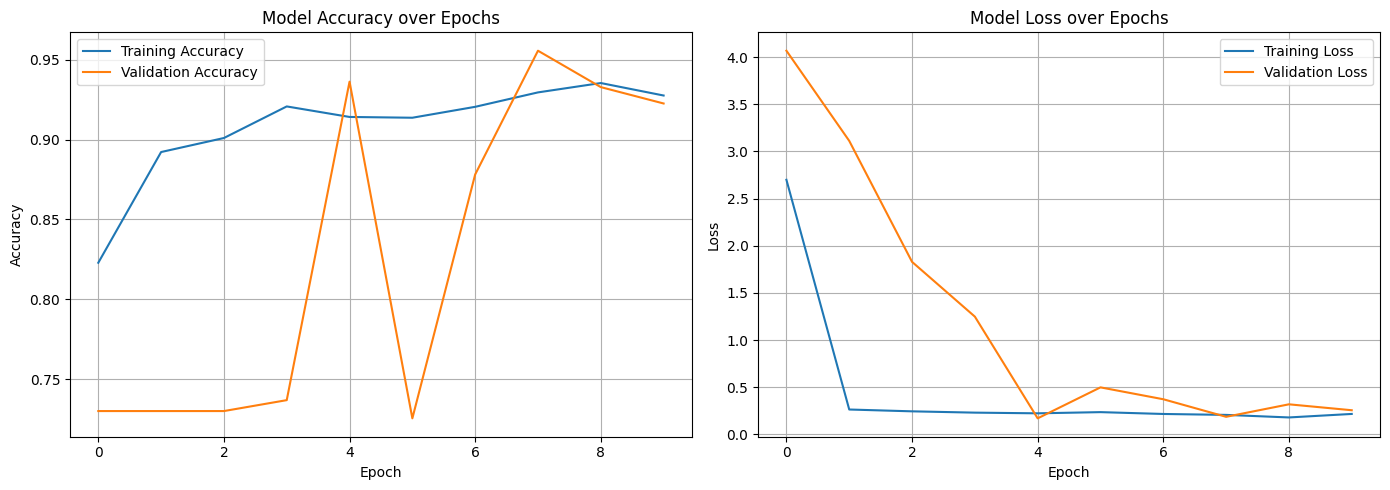

Training history plot saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history_variation1.png', dpi=150)
plt.show()
print("Training history plot saved.")

In [ ]:
print("Evaluating on test set...\n")

# Get true labels from the test generator
y_true = test_gen.classes

# Get predicted probabilities from the model
y_pred_prob = model.predict(test_gen, verbose=1).flatten()

# Convert probabilities to class predictions using threshold 0.5
# > 0.5 = PNEUMONIA (1), <= 0.5 = NORMAL (0)
y_pred = (y_pred_prob > 0.5).astype(int)

# --- Accuracy ---
accuracy = np.mean(y_true == y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# --- Precision, Recall, F1 (from Lecture 6) ---
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

Evaluating on test set...

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step

Accuracy: 0.9215 (92.15%)

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.80      0.94      0.87       238
   PNEUMONIA       0.98      0.91      0.94       641

    accuracy                           0.92       879
   macro avg       0.89      0.93      0.91       879
weighted avg       0.93      0.92      0.92       879



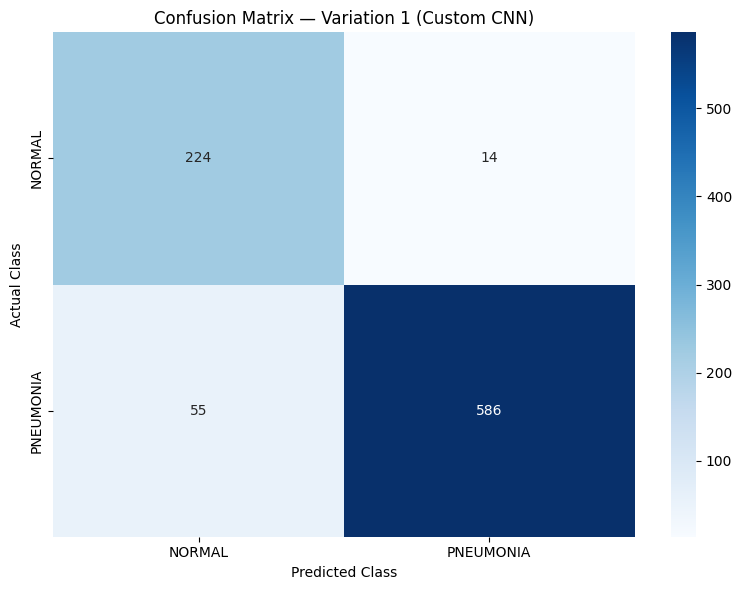


True Positives  (TP): 586  — Pneumonia correctly identified
True Negatives  (TN): 224  — Normal correctly identified
False Positives (FP): 14  — Normal incorrectly flagged as Pneumonia
False Negatives (FN): 55  — Pneumonia missed (most dangerous error)

Precision:   0.9767
Recall:      0.9142
F1 Score:    0.9444


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)
plt.title('Confusion Matrix — Variation 1 (Custom CNN)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_variation1.png', dpi=150)
plt.show()

# Print individual values for easy reading
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (TP): {tp}  — Pneumonia correctly identified")
print(f"True Negatives  (TN): {tn}  — Normal correctly identified")
print(f"False Positives (FP): {fp}  — Normal incorrectly flagged as Pneumonia")
print(f"False Negatives (FN): {fn}  — Pneumonia missed (most dangerous error)")

precision  = tp / (tp + fp)
recall     = tp / (tp + fn)
f1         = 2 * (precision * recall) / (precision + recall)

print(f"\nPrecision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")

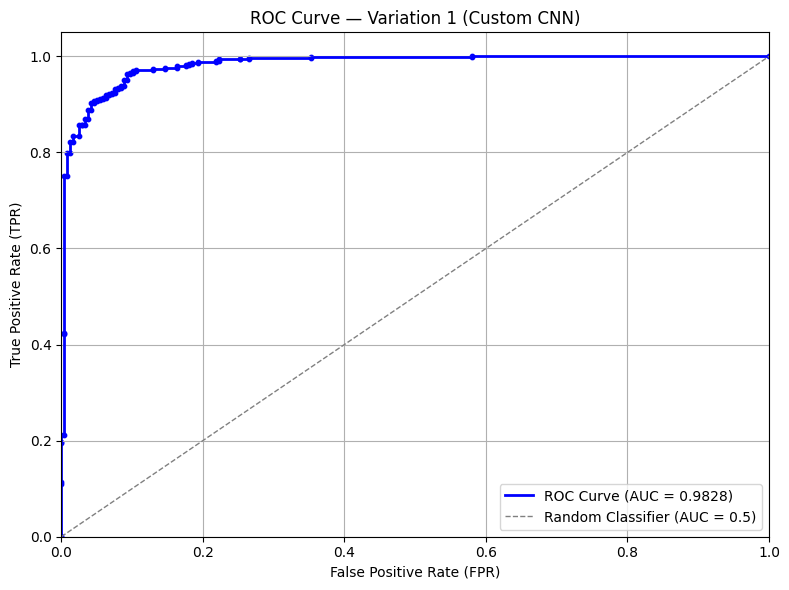


AUC Score: 0.9828


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1,
         linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.scatter(fpr, tpr, color='blue', s=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Variation 1 (Custom CNN)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/roc_curve_variation1.png', dpi=150)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")

In [ ]:
print("=" * 55)
print("  VARIATION 1 — CUSTOM CNN — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Accuracy:  {accuracy*100:.2f}%")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  AUC:       {roc_auc:.4f}")
print("=" * 55)
print("\nFiles saved to Google Drive:")
print("  best_model_variation1.keras")
print("  training_history_variation1.png")
print("  confusion_matrix_variation1.png")
print("  roc_curve_variation1.png")


  VARIATION 1 — CUSTOM CNN — FINAL RESULTS SUMMARY
  Accuracy:  92.15%
  Precision: 0.9767
  Recall:    0.9142
  F1 Score:  0.9444
  AUC:       0.9828

Files saved to Google Drive:
  best_model_variation1.keras
  training_history_variation1.png
  confusion_matrix_variation1.png
  roc_curve_variation1.png
